# Stock Price Prediction Using Transformer Model
EE 559 - Machine Learning I

Name: Sungje Park


In [1]:
import pandas as pd
import jax
import jax.numpy as jnp
import optax
import numpy as np
from tqdm import tqdm
from functools import partial
import matplotlib.pyplot as plt
from models import TransformerModel

## Processing Data

In [2]:
train_data = pd.read_pickle('datasets/wide/train_data.pickle')
valid_data = pd.read_pickle('datasets/wide/valid_data.pickle')
test_data = pd.read_pickle('datasets/wide/test_data.pickle')

train_mask = pd.read_pickle('datasets/wide/train_mask.pickle')
valid_mask = pd.read_pickle('datasets/wide/valid_mask.pickle')
test_mask = pd.read_pickle('datasets/wide/test_mask.pickle')

In [3]:
train_data.head()

CAT                                         \
           Open_ret_prev_close High_ret_prev_close Low_ret_prev_close   
Date                                                                    
1962-01-03            0.000000            0.009740          -0.009740   
1962-01-04            0.022508            0.054662           0.022508   
1962-01-05            0.000000            0.021944          -0.003135   
1962-01-08            0.000000            0.015528          -0.006211   
1962-01-09            0.000000            0.018519          -0.009259   

                                                               \
           Close_ret_prev_close rel_volume_yday rel_adj_close   
Date                                                            
1962-01-03             0.009740       -0.044109      0.009739   
1962-01-04             0.025724        1.064293      0.025724   
1962-01-05             0.009404       -0.517177      0.009405   
1962-01-08             0.006211        0.247459      0.006211   
1962-01-09             0.009259        0.411786      0.009260   

                                                 KO                      \
           target_rel_adj_close Open_ret_prev_close High_ret_prev_close   
Date                                                                      
1962-01-03             0.025724           -0.014851           -0.014851   
1962-01-04             0.009405            0.002532            0.015190   
1962-01-05             0.006211            0.000000            0.012563   
1962-01-08             0.009260           -0.007712           -0.007712   
1962-01-09            -0.012233            0.000000            0.023377   

                               ...            ABEO                \
           Low_ret_prev_close  ... rel_volume_yday rel_adj_close   
Date                           ...                                 
1962-01-03          -0.037129  ...             0.0           0.0   
1962-01-04           0.002532  ...             0.0           0.0   
1962-01-05          -0.025126  ...             0.0           0.0   
1962-01-08          -0.029563  ...             0.0           0.0   
1962-01-09          -0.007792  ...             0.0           0.0   

                                                 GL                      \
           target_rel_adj_close Open_ret_prev_close High_ret_prev_close   
Date                                                                      
1962-01-03                  0.0                 0.0                 0.0   
1962-01-04                  0.0                 0.0                 0.0   
1962-01-05                  0.0                 0.0                 0.0   
1962-01-08                  0.0                 0.0                 0.0   
1962-01-09                  0.0                 0.0                 0.0   

                                                                    \
           Low_ret_prev_close Close_ret_prev_close rel_volume_yday   
Date                                                                 
1962-01-03                0.0                  0.0             0.0   
1962-01-04                0.0                  0.0             0.0   
1962-01-05                0.0                  0.0             0.0   
1962-01-08                0.0                  0.0             0.0   
1962-01-09                0.0                  0.0             0.0   

                                               
           rel_adj_close target_rel_adj_close  
Date                                           
1962-01-03           0.0                  0.0  
1962-01-04           0.0                  0.0  
1962-01-05           0.0                  0.0  
1962-01-08           0.0                  0.0  
1962-01-09           0.0                  0.0  

[5 rows x 3500 columns]

In [4]:
train_mask.head()

CAT                                         \
           Open_ret_prev_close High_ret_prev_close Low_ret_prev_close   
Date                                                                    
1962-01-03                True                True               True   
1962-01-04                True                True               True   
1962-01-05                True                True               True   
1962-01-08                True                True               True   
1962-01-09                True                True               True   

                                                               \
           Close_ret_prev_close rel_volume_yday rel_adj_close   
Date                                                            
1962-01-03                 True            True          True   
1962-01-04                 True            True          True   
1962-01-05                 True            True          True   
1962-01-08                 True            True          True   
1962-01-09                 True            True          True   

                                                 KO                      \
           target_rel_adj_close Open_ret_prev_close High_ret_prev_close   
Date                                                                      
1962-01-03                 True                True                True   
1962-01-04                 True                True                True   
1962-01-05                 True                True                True   
1962-01-08                 True                True                True   
1962-01-09                 True                True                True   

                               ...            ABEO                \
           Low_ret_prev_close  ... rel_volume_yday rel_adj_close   
Date                           ...                                 
1962-01-03               True  ...           False         False   
1962-01-04               True  ...           False         False   
1962-01-05               True  ...           False         False   
1962-01-08               True  ...           False         False   
1962-01-09               True  ...           False         False   

                                                 GL                      \
           target_rel_adj_close Open_ret_prev_close High_ret_prev_close   
Date                                                                      
1962-01-03                False               False               False   
1962-01-04                False               False               False   
1962-01-05                False               False               False   
1962-01-08                False               False               False   
1962-01-09                False               False               False   

                                                                    \
           Low_ret_prev_close Close_ret_prev_close rel_volume_yday   
Date                                                                 
1962-01-03              False                False           False   
1962-01-04              False                False           False   
1962-01-05              False                False           False   
1962-01-08              False                False           False   
1962-01-09              False                False           False   

                                               
           rel_adj_close target_rel_adj_close  
Date                                           
1962-01-03         False                False  
1962-01-04         False                False  
1962-01-05         False                False  
1962-01-08         False                False  
1962-01-09         False                False  

[5 rows x 3500 columns]

In [5]:
def data_processing(data, mask):
    feature_df = data.drop(columns=['target_rel_adj_close'], level=1)
    target_df = data.xs('target_rel_adj_close', level=1, axis=1)
    mask_df = mask.xs('target_rel_adj_close', level=1, axis=1)

    feature_array = jnp.asarray(feature_df.to_numpy())
    target_array = jnp.asarray(target_df.to_numpy())[..., jnp.newaxis]
    mask_array = jnp.asarray(mask_df.to_numpy())

    num_tokens = target_array.shape[1]
    num_features = feature_array.shape[1] // num_tokens
    data_array = feature_array.reshape(feature_array.shape[0], num_tokens, num_features)

    return data_array, target_array, mask_array

In [6]:
train_data_x, train_data_y, train_mask_array = data_processing(train_data, train_mask)
valid_data_x, valid_data_y, valid_mask_array = data_processing(valid_data, valid_mask)
test_data_x, test_data_y, test_mask_array = data_processing(test_data, test_mask)
print(train_data_x.shape, train_data_y.shape, train_mask_array.shape)

(10262, 500, 6) (10262, 500, 1) (10262, 500)


Ratio of NaN filled data

In [7]:
print(jnp.sum(train_mask_array)/train_mask_array.size)
print(jnp.sum(valid_mask_array)/valid_mask_array.size)
print(jnp.sum(test_mask_array)/test_mask_array.size)

0.46335238
1.0
1.0


Sub-sampling for testing

In [8]:
# train_data_x = train_data_x[:,:50]
# train_data_y = train_data_y[:,:50]
# train_mask_array = train_mask_array[:,:50]
# print(train_data_x.shape, train_data_y.shape, train_mask_array.shape)
# valid_data_x = valid_data_x[:,:50]
# valid_data_y = valid_data_y[:,:50]
# valid_mask_array = valid_mask_array[:,:50]

# test_data_x = test_data_x[:,:50]
# test_data_y = test_data_y[:,:50]
# test_mask_array = test_mask_array[:,:50]

## Model Training

In [9]:
lr = 1e-4
batch_size = 512
seed = 1234
num_epochs = 10000

In [10]:
model = TransformerModel()
params = model.init(jax.random.PRNGKey(0), train_data_x[:1], train_mask_array[:1])
num_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters in the model: {num_params}")

Number of parameters in the model: 727425


In [11]:
def mse_loss(params,model, x, y, mask):
    preds = model.apply(params, x, mask)
    loss = jnp.mean(((preds - y) ** 2) * mask[..., None])
    return loss

def subsample_data(key,x,y,mask, batch_size):
    indices = jax.random.choice(key, x.shape[0], (batch_size,), replace=False)
    return x[indices], y[indices], mask[indices]

In [12]:
mse_loss(params, model, train_data_x[:10], train_data_y[:10], train_mask_array[:10])

Array(0.00480535, dtype=float32)

In [13]:
optimizer = optax.adam(learning_rate=lr)
opt_state = optimizer.init(params)

In [14]:
@partial(jax.jit, static_argnums=(0,))
def step(model,params,opt_state, x, y, mask, rng_key):
    rng_key, subkey = jax.random.split(rng_key)
    x,y,mask = subsample_data(subkey,x,y,mask, batch_size=batch_size)
    loss, grads = jax.value_and_grad(mse_loss)(params, model, x, y, mask)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, rng_key

In [15]:
rng_key = jax.random.PRNGKey(seed)
loss_track = []
v_loss_track = []
for _ in tqdm(range(num_epochs)):
    params,opt_state,loss,rng_key = step(model,params,opt_state,train_data_x,train_data_y,train_mask_array,rng_key)
    valid_x_temp, valid_y_temp, valid_mask_temp = subsample_data(rng_key, valid_data_x, valid_data_y, valid_mask_array, batch_size=batch_size)
    v_loss = mse_loss(params, model, valid_x_temp, valid_y_temp, valid_mask_temp)
    loss_track.append(loss)
    v_loss_track.append(v_loss)

100%|██████████| 10000/10000 [22:02<00:00,  7.56it/s]


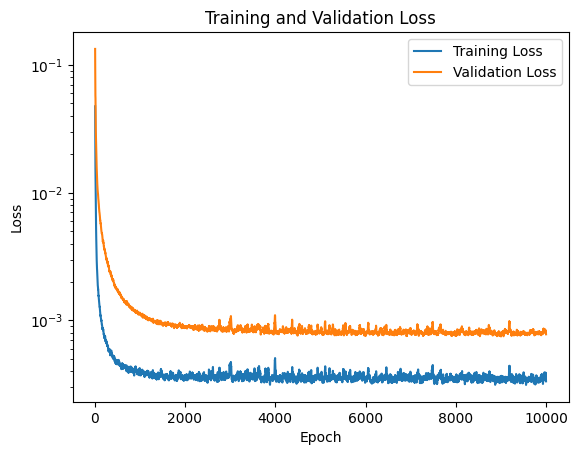

In [16]:
rolling_loss = pd.Series(loss_track).rolling(window=10).mean()
rolling_v_loss = pd.Series(v_loss_track).rolling(window=10).mean()

plt.plot(rolling_loss)
plt.plot(rolling_v_loss)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend(['Training Loss', 'Validation Loss'])
plt.savefig('figures/spatial_training_loss.png')
plt.show()

In [17]:
@jax.jit
def evaluate(x,y,mask):
    pred = model.apply(params,x,mask)
    mse = jnp.mean((pred - y)**2,where=mask[..., None])
    sign_pred = jnp.sign(pred.flatten())
    sign_true = jnp.sign(y.flatten())
    accuracy = jnp.mean(sign_pred == sign_true, where=mask.flatten())
    return mse, accuracy
    
@jax.jit
def raw_eval(x,y,mask):
    pred = model.apply(params,x,mask)
    mse = (pred - y)**2
    sign_pred = jnp.sign(pred.flatten())
    sign_true = jnp.sign(y.flatten())
    accuracy = sign_pred == sign_true
    positive_pred = sign_pred > 0
    positive_true = sign_true > 0
    return mse, accuracy, positive_pred, positive_true

def batch_evaluate(x,y,mask,batch_size):
    num_samples = x.shape[0]
    mse = []
    accuracy = []
    positive_pred = []
    positive_true = []
    for i in range(0, num_samples, batch_size):
        batch_x = x[i:i+batch_size]
        batch_y = y[i:i+batch_size]
        batch_mask = mask[i:i+batch_size]
        batch_mse, batch_acc, batch_pos_pred, batch_pos_true = raw_eval(batch_x, batch_y, batch_mask)
        mse.append(batch_mse)
        accuracy.append(batch_acc)
        positive_pred.append(batch_pos_pred)
        positive_true.append(batch_pos_true)
    mse = jnp.mean(jnp.concatenate(mse),where=mask[..., None])
    accuracy = jnp.mean(jnp.concatenate(accuracy),where=mask.flatten())
    flat_mask = mask.flatten()
    pred_pos = jnp.concatenate(positive_pred)
    true_pos = jnp.concatenate(positive_true)
    tp = jnp.sum(pred_pos & true_pos & flat_mask)
    fp = jnp.sum(pred_pos & ~true_pos & flat_mask)
    fn = jnp.sum((~pred_pos) & true_pos & flat_mask)
    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return mse, accuracy, precision, recall, f1
        
def print_eval_metrics(mse, acc, precision, recall, f1, dataset_name):
    print(f"{dataset_name} MSE: {mse:.6f}, Sign Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

In [18]:
eval_batch = 1024

train_mse, train_acc, train_precision, train_recall, train_f1 = batch_evaluate(train_data_x, train_data_y,train_mask_array,eval_batch)
print_eval_metrics(train_mse, train_acc, train_precision, train_recall, train_f1, "Train")
valid_mse, valid_acc, valid_precision, valid_recall, valid_f1 = batch_evaluate(valid_data_x, valid_data_y,valid_mask_array,eval_batch)
print_eval_metrics(valid_mse, valid_acc, valid_precision, valid_recall, valid_f1, "Validation")
test_mse, test_acc, test_precision, test_recall, test_f1 = batch_evaluate(test_data_x, test_data_y,test_mask_array,eval_batch)
print_eval_metrics(test_mse, test_acc, test_precision, test_recall, test_f1, "Test")

Train MSE: 0.000738, Sign Accuracy: 0.5625, Precision: 0.4408, Recall: 0.3041, F1: 0.3599
Validation MSE: 0.000788, Sign Accuracy: 0.5007, Precision: 0.4870, Recall: 0.2580, F1: 0.3374
Test MSE: 0.000752, Sign Accuracy: 0.4985, Precision: 0.5006, Recall: 0.2048, F1: 0.2907


## Spatial + Temporal Dependencies


In [19]:
def data_processing_with_lookback(data, mask, lookback_count=10):
    feature_df = data.drop(columns=['target_rel_adj_close'], level=1)
    target_df = data.xs('target_rel_adj_close', level=1, axis=1)
    mask_df = mask.xs('target_rel_adj_close', level=1, axis=1)

    feature_array = jnp.asarray(feature_df.to_numpy())
    target_array = jnp.asarray(target_df.to_numpy())[..., jnp.newaxis]
    mask_array = jnp.asarray(mask_df.to_numpy())

    num_tokens = target_array.shape[1]
    num_features = feature_array.shape[1] // num_tokens
    feature_array = feature_array.reshape(feature_array.shape[0], num_tokens, num_features)
    
    # Create sequences with lookback
    num_samples = feature_array.shape[0]
    sequences_x = []
    sequences_y = []
    sequences_mask = []
    
    for i in range(num_samples - lookback_count):
        sequences_x.append(feature_array[i:i+lookback_count])
        sequences_y.append(target_array[i+lookback_count])
        sequences_mask.append(mask_array[i:i+lookback_count])
    
    data_array = jnp.stack(sequences_x)
    target_array = jnp.stack(sequences_y)
    mask_array = jnp.stack(sequences_mask)
    
    return data_array, target_array, mask_array

In [20]:
train_data_x, train_data_y, train_mask_array = data_processing_with_lookback(train_data, train_mask)
valid_data_x, valid_data_y, valid_mask_array = data_processing_with_lookback(valid_data, valid_mask)
test_data_x, test_data_y, test_mask_array = data_processing_with_lookback(test_data, test_mask)
print(train_data_x.shape, train_data_y.shape, train_mask_array.shape)

(10252, 10, 500, 6) (10252, 500, 1) (10252, 10, 500)


## Model Training

In [21]:
lr = 1e-4
batch_size = 512
seed = 1234
num_epochs = 10000

In [22]:
model = TransformerModel(temporal_attention=True)
params = model.init(jax.random.PRNGKey(0), train_data_x[:1], train_mask_array[:1])
num_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters in the model: {num_params}")

Number of parameters in the model: 861185


In [23]:
def mse_loss(params,model, x, y, mask):
    preds = model.apply(params, x, mask)
    loss = jnp.mean(((preds - y) ** 2) * mask[:,-1,:, None])
    return loss

def subsample_data(key,x,y,mask, batch_size):
    indices = jax.random.choice(key, x.shape[0], (batch_size,), replace=False)
    return x[indices], y[indices], mask[indices]

In [24]:
mse_loss(params, model, train_data_x[:10], train_data_y[:10], train_mask_array[:10])

Array(0.01080273, dtype=float32)

In [25]:
optimizer = optax.adam(learning_rate=lr)
opt_state = optimizer.init(params)

In [26]:
@partial(jax.jit, static_argnums=(0,))
def step(model,params,opt_state, x, y, mask, rng_key):
    rng_key, subkey = jax.random.split(rng_key)
    x,y,mask = subsample_data(subkey,x,y,mask, batch_size=batch_size)
    loss, grads = jax.value_and_grad(mse_loss)(params, model, x, y, mask)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, rng_key

In [27]:
rng_key = jax.random.PRNGKey(seed)
loss_track = []
v_loss_track = []
for _ in tqdm(range(num_epochs)):
    params,opt_state,loss,rng_key = step(model,params,opt_state,train_data_x,train_data_y,train_mask_array,rng_key)
    valid_x_temp, valid_y_temp, valid_mask_temp = subsample_data(rng_key, valid_data_x, valid_data_y, valid_mask_array, batch_size=batch_size)
    v_loss = mse_loss(params, model, valid_x_temp, valid_y_temp, valid_mask_temp)
    loss_track.append(loss)
    v_loss_track.append(v_loss)

  0%|          | 0/10000 [00:00<?, ?it/s]W0504 20:36:25.511493  392032 autotuner.cc:637] No reference output found even though buffer checking 
W0504 20:36:26.835013  392043 autotuner.cc:637] No reference output found even though buffer checking 
W0504 20:36:26.869686  392032 autotuner.cc:637] No reference output found even though buffer checking 
W0504 20:36:26.885347  392041 autotuner.cc:637] No reference output found even though buffer checking 
W0504 20:36:26.979612  392035 autotuner.cc:637] No reference output found even though buffer checking 
W0504 20:36:27.014271  392032 autotuner.cc:637] No reference output found even though buffer checking 
100%|██████████| 10000/10000 [34:40<00:00,  4.81it/s]


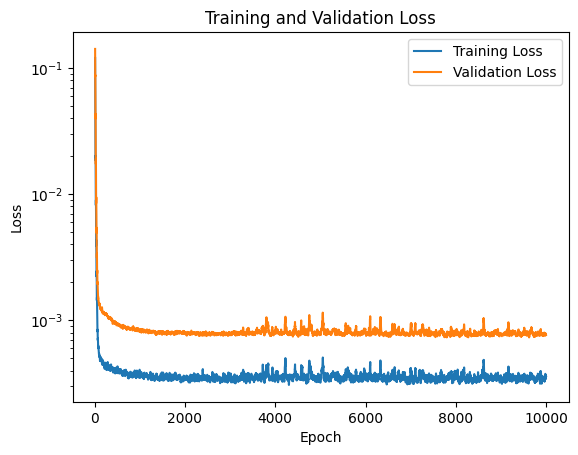

In [28]:
rolling_loss = pd.Series(loss_track).rolling(window=10).mean()
rolling_v_loss = pd.Series(v_loss_track).rolling(window=10).mean()

plt.plot(rolling_loss)
plt.plot(rolling_v_loss)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend(['Training Loss', 'Validation Loss'])
plt.savefig('figures/spatial_temporal_training_loss.png')
plt.show()

In [29]:
@jax.jit
def raw_eval(x,y,mask):
    pred = model.apply(params,x,mask)
    mse = (pred - y)**2
    sign_pred = jnp.sign(pred.flatten())
    sign_true = jnp.sign(y.flatten())
    accuracy = sign_pred == sign_true
    positive_pred = sign_pred > 0
    positive_true = sign_true > 0
    return mse, accuracy, positive_pred, positive_true

def batch_evaluate(x,y,mask,batch_size):
    num_samples = x.shape[0]
    mse = []
    accuracy = []
    positive_pred = []
    positive_true = []
    for i in range(0, num_samples, batch_size):
        batch_x = x[i:i+batch_size]
        batch_y = y[i:i+batch_size]
        batch_mask = mask[i:i+batch_size]
        batch_mse, batch_acc, batch_pos_pred, batch_pos_true = raw_eval(batch_x, batch_y, batch_mask)
        mse.append(batch_mse)
        accuracy.append(batch_acc)
        positive_pred.append(batch_pos_pred)
        positive_true.append(batch_pos_true)
    mse = jnp.mean(jnp.concatenate(mse),where=mask[:,-1,:, None])
    accuracy = jnp.mean(jnp.concatenate(accuracy),where=mask[:,-1].flatten())
    flat_mask = mask[:,-1].flatten()
    pred_pos = jnp.concatenate(positive_pred)
    true_pos = jnp.concatenate(positive_true)
    tp = jnp.sum(pred_pos & true_pos & flat_mask)
    fp = jnp.sum(pred_pos & ~true_pos & flat_mask)
    fn = jnp.sum((~pred_pos) & true_pos & flat_mask)
    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return mse, accuracy, precision, recall, f1
        
def print_eval_metrics(mse, acc, precision, recall, f1, dataset_name):
    print(f"{dataset_name} MSE: {mse:.6f}, Sign Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

In [30]:
eval_batch = 1024

train_mse, train_acc, train_precision, train_recall, train_f1 = batch_evaluate(train_data_x, train_data_y,train_mask_array,eval_batch)
print_eval_metrics(train_mse, train_acc, train_precision, train_recall, train_f1, "Train")
valid_mse, valid_acc, valid_precision, valid_recall, valid_f1 = batch_evaluate(valid_data_x, valid_data_y,valid_mask_array,eval_batch)
print_eval_metrics(valid_mse, valid_acc, valid_precision, valid_recall, valid_f1, "Validation")
test_mse, test_acc, test_precision, test_recall, test_f1 = batch_evaluate(test_data_x, test_data_y,test_mask_array,eval_batch)
print_eval_metrics(test_mse, test_acc, test_precision, test_recall, test_f1, "Test")

W0504 21:11:05.426242  392045 autotuner.cc:637] No reference output found even though buffer checking 
W0504 21:11:05.484710  392041 autotuner.cc:637] No reference output found even though buffer checking 


Train MSE: 0.000759, Sign Accuracy: 0.4017, Precision: 0.4015, Recall: 0.9993, F1: 0.5729


W0504 21:11:15.178605  392034 autotuner.cc:637] No reference output found even though buffer checking 
W0504 21:11:15.661694  392044 autotuner.cc:637] No reference output found even though buffer checking 


Validation MSE: 0.000788, Sign Accuracy: 0.4925, Precision: 0.4922, Recall: 0.9861, F1: 0.6567


W0504 21:11:19.181464  392032 autotuner.cc:637] No reference output found even though buffer checking 
W0504 21:11:19.626263  392033 autotuner.cc:637] No reference output found even though buffer checking 


Test MSE: 0.000760, Sign Accuracy: 0.5032, Precision: 0.5027, Recall: 0.9727, F1: 0.6628
